# WP5 · 06 — Population-product sensitivity (plan §3.5)

**The question.** WP5's headline is that *how you construct exposure* moves exposure: population
weighting moves Sri Lankan district rainfall by 3.40 mm/week and weekly maximum temperature by
0.387 °C (`wp5_03`, plan §3.2). The obvious reviewer reply is that the result is an artifact of
**WorldPop** — one modelled population surface among several, with its own dasymetric assumptions.

So this notebook asks the meta-MAUP question the plan's §3.5 poses: **does the choice of population
*product* move exposure as far as the choice to population-weight at all?** If it does, WP5's result
is a statement about WorldPop. If it does not, WP5's result survives the substitution.

**Scope, stated up front.** §3.5 has two halves and only the first is runnable here. *"Rebuild Build B
weights under an alternative population product"* needs the products and the staged climate — all on
this machine. *"Recompute ΔNB at p\* under each layer"* needs the fitted model, which the repo does
not hold (the §8 / §5.1 blocker). This notebook does the first half and stops at the boundary, the
same split `wp5_03` found between §3.2 and §3.3.

**Products compared** — all free, all anonymous, no account:

| product | producer | method | epoch |
|---|---|---|---|
| WorldPop UN-adjusted 100 m | WorldPop / Southampton | random-forest dasymetric, unconstrained, UN-adjusted | 2020 |
| WorldPop R2025A constrained 100 m | WorldPop | **constrained** to built settlement, newer release | 2020 |
| GHS-POP R2023A 3 arcsec | JRC / European Commission | built-up-surface dasymetric (GHS-BUILT-S) | 2020 |
| census district totals | — | uniform within district | — |

The fourth is included because §3.5 names it, and §12 shows it is **degenerate by construction**.

## 1 · Setup, and the frame check

In [1]:
import json, hashlib, zipfile, re, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.features
from rasterio.windows import Window
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
POPR = REPO / "data_quarantine" / "population_r2025a"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
GHSL = QUAR / "ghsl"
ERA5 = QUAR / "era5_0p25_window"
CHIRPS = QUAR / "chirps_window"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
GHSL.mkdir(parents=True, exist_ok=True)

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
rdhs  = gpd.read_file(GEOM)
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_geom == prov0["geometry_sha256_16"], "geometry differs from the M6 frame — stop"

SEED, CRS_EA = prov0["seed"], prov0["crs_equal_area"]
N_UNITS = len(rdhs)
print("frame   :", N_UNITS, "RDHS | geometry sha", sha_geom)
print("seed    :", SEED)
print("staged  : era5", len(list(ERA5.glob("*.npz"))), "npz | chirps", len(list(CHIRPS.glob("*.npz"))), "npz")

frame   : 26 RDHS | geometry sha 9e5e2c0a541ecac1
seed    : 20260612
staged  : era5 16 npz | chirps 8 npz


## 2 · Configuration

`POP_YEAR = 2020` throughout. That is the newest WorldPop UN-adjusted vintage staged (`wp5_00` §11)
and it is also a GHS-POP epoch year, so the three products are compared **at the same epoch** and
the comparison isolates *method*, not *date*.

The two climate grids are the ones the frozen twins were built on — ERA5 0.25° for temperature
(`wp5_02`) and CHIRPS p05 for rainfall (`wp5_01`). Both grid definitions are quoted from `wp5_00`,
where they were verified against real granules; §7 and §8 re-assert them against the staged windows
rather than trusting the constants.

In [2]:
POP_YEAR = 2020

GRIDS = {
    "era5_0p25":  dict(res=0.25, edge_lon=-180.125, edge_lat=90.125, var="t2m / d2m"),
    "chirps_p05": dict(res=0.05, edge_lon=-180.0,   edge_lat=50.0,   var="precipitation"),
}

GHSL_BASE = ("https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/"
             "GHS_POP_E2020_GLOBE_R2023A_4326_3ss/V1-0/tiles/"
             "GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_%s.zip")
GHSL_TILES = ["R8_C26", "R8_C27", "R9_C26", "R9_C27"]   # 10-deg tiles; §3 shows why all four

for k, g in GRIDS.items():
    print(f"{k:<12} {g['res']}deg   {g['var']}")
print("population epoch:", POP_YEAR)

era5_0p25    0.25deg   t2m / d2m
chirps_p05   0.05deg   precipitation
population epoch: 2020


## 3 · Staging GHS-POP — one global grid, integer windows, and a trap worth measuring

GHS-POP R2023A ships as 10°×10° tiles. Sri Lanka spans 79.52–81.88 °E and 5.92–9.84 °N, which
straddles the 80 °E tile seam **and** the 10 °N tile seam, so all **four** neighbouring tiles are
needed. Downloading only the two southern ones silently truncates Jaffna, Kilinochchi and
Mullaitivu — the northern districts — leaving a table that is complete-looking and wrong.

In [3]:
for t in GHSL_TILES:
    z = GHSL / (t + ".zip")
    if not z.exists():
        urllib.request.urlretrieve(GHSL_BASE % t, z)
    d = GHSL / t
    if not d.exists():
        with zipfile.ZipFile(z) as zf:
            zf.extractall(d)
    print(f"{t}  {z.stat().st_size/1e6:>7.1f} MB  ->  {[p.name for p in d.glob('*.tif')][0][:56]}")

R8_C26    159.3 MB  ->  GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_R8_C26.tif
R8_C27     20.9 MB  ->  GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_R8_C27.tif
R9_C26      9.4 MB  ->  GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_R9_C26.tif
R9_C27     18.5 MB  ->  GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_R9_C27.tif


In [4]:
tiles = {re.search(r"_(R\d+_C\d+)\.tif$", str(p)).group(1): p
         for p in sorted(GHSL.glob("*/*.tif"))}
meta = {}
for name, p in tiles.items():
    with rasterio.open(p) as s:
        meta[name] = (s.transform, s.shape, s.nodata)
        print(f"{name}  {s.shape}  res {s.transform.a:.10f}  origin ({s.transform.c:.7f}, {s.transform.f:.7f})")

# the four tiles must lie on ONE global grid, offset by whole tiles, or pasting them is meaningless
T0 = meta["R8_C26"][0]
RES = T0.a
for name, (T, shape, _) in meta.items():
    R, Cc = map(int, re.match(r"R(\d+)_C(\d+)", name).groups())
    dc, dr = (T.c - T0.c) / RES, (T.f - T0.f) / -RES
    assert abs(dc - (Cc - 26) * 12000) < 1e-6 and abs(dr - (R - 8) * 12000) < 1e-6, f"{name} off-grid"
print("\nall four tiles share one global grid, 12000 px per 10 deg — integer offsets confirmed")

R8_C26  (12000, 12000)  res 0.0008333333  origin (69.9920831, 19.0995835)
R8_C27  (12000, 12000)  res 0.0008333333  origin (79.9920830, 19.0995835)
R9_C26  (12000, 12000)  res 0.0008333333  origin (69.9920831, 9.0995835)
R9_C27  (12000, 12000)  res 0.0008333333  origin (79.9920830, 9.0995835)

all four tiles share one global grid, 12000 px per 10 deg — integer offsets confirmed


### 3.1 · The trap: `merge(bounds=…)` does not snap to the source grid

The obvious way to build a Sri Lanka mosaic is `rasterio.merge.merge(srcs, bounds=…)`. It computes
the output transform **from the requested bounds**, not from the source grid, and then resamples
each source into it — nearest-neighbour by default.

That is wrong here in a way that does not raise: these pixels are **population counts**, not a
continuous field. A half-pixel shift resampled nearest duplicates some 100 m cells and drops others,
which moves people. The cell below measures the offset instead of assuming it is zero.

In [5]:
from rasterio.merge import merge as _merge

_srcs = [rasterio.open(p) for p in tiles.values()]
_mos, _T = _merge(_srcs, bounds=tuple(rdhs.total_bounds))
for s in _srcs:
    s.close()

off_c = (_T.c - T0.c) / RES
off_r = (_T.f - T0.f) / -RES
print(f"merge(bounds=) origin offset from the GHSL grid: {off_c % 1:.4f} px in x, {off_r % 1:.4f} px in y")
print("  -> a sub-pixel offset, nearest-resampled. Not used. Section 3.2 pastes on the native grid.")

merge(bounds=) origin offset from the GHSL grid: 0.0786 px in x, 0.4646 px in y
  -> a sub-pixel offset, nearest-resampled. Not used. Section 3.2 pastes on the native grid.


### 3.2 · The correct staging: integer windows, no resampling

Because the four tiles share one integer grid, the Sri Lanka window is an integer sub-grid of it.
Each tile is read through a `Window` and pasted at an integer offset — **no resampling of any
kind**, so every source pixel value survives exactly.

In [6]:
l, b, r, t = rdhs.total_bounds
LON0, LAT0 = T0.c, T0.f                                   # global anchor: upper-left of R8_C26
c0, c1 = int(np.floor((l - LON0) / RES)), int(np.ceil((r - LON0) / RES))
r0, r1 = int(np.floor((LAT0 - t) / RES)), int(np.ceil((LAT0 - b) / RES))

ghsl = np.zeros((r1 - r0, c1 - c0), np.float64)
for name, p in tiles.items():
    R, Cc = map(int, re.match(r"R(\d+)_C(\d+)", name).groups())
    orow, ocol = (R - 8) * 12000, (Cc - 26) * 12000       # tile origin in global index space
    sr0, sr1 = max(r0 - orow, 0), min(r1 - orow, 12000)
    sc0, sc1 = max(c0 - ocol, 0), min(c1 - ocol, 12000)
    if sr1 <= sr0 or sc1 <= sc0:
        continue
    with rasterio.open(p) as s:
        blk = s.read(1, window=Window(sc0, sr0, sc1 - sc0, sr1 - sr0))
    ghsl[sr0 + orow - r0: sr1 + orow - r0, sc0 + ocol - c0: sc1 + ocol - c0] = blk
    print(f"  {name}: pasted {blk.shape}  {blk.sum()/1e6:>6.3f} M people")

T_GHSL = rasterio.Affine(RES, 0, LON0 + c0 * RES, 0, -RES, LAT0 - r0 * RES)
ghsl[ghsl < 0] = 0.0                                       # GHSL carries no negative counts; guard anyway
print(f"\nGHSL window {ghsl.shape}  total {ghsl.sum()/1e6:.4f} M  max cell {ghsl.max():.0f}")
assert ghsl.sum() > 15e6, "implausible national total — check the tile set"

  R8_C26: pasted (884, 565)   0.127 M people


  R8_C27: pasted (884, 2265)   0.606 M people


  R9_C26: pasted (3818, 565)   5.181 M people
  R9_C27: pasted (3818, 2265)  15.801 M people

GHSL window (4702, 2830)  total 21.7151 M  max cell 3720


## 4 · What the products disagree about *before* any weighting

Two things matter before touching climate.

**National total does not matter at all.** Build B's weights are normalised **within each district**,
so a product's overall scaling cancels exactly. What matters is only the *shape* of the population
surface inside a district.

**Coastal capture does matter**, and it is an open WP5 item: `wp5_00` §7 and M6 notebook 03 §7 both
found ~1.4% of WorldPop's people falling outside the 26 polygons on a centre-in-polygon test, and
the README lists "accept and report, or switch to fractional-coverage weighting" as an unresolved
decision. The three products answer it.

In [7]:
def load_raster(p):
    with rasterio.open(p) as s:
        a = s.read(1).astype(np.float64)
        if s.nodata is not None:
            a[a == s.nodata] = 0.0
        a[a < 0] = 0.0
        return a, s.transform

PRODUCTS = {}
PRODUCTS["worldpop_unadj"]  = load_raster(M6 / "worldpop" / f"lka_ppp_{POP_YEAR}_UNadj.tif")
PRODUCTS["worldpop_r2025a"] = load_raster(POPR / f"lka_pop_{POP_YEAR}_CN_100m_R2025A_v1.tif")
PRODUCTS["ghsl_r2023a"]     = (ghsl, T_GHSL)

rows = []
for name, (a, T) in PRODUCTS.items():
    H, W = a.shape
    d = rasterio.features.rasterize([(g, i + 1) for i, g in enumerate(rdhs.geometry)],
                                    out_shape=(H, W), transform=T, fill=0, dtype="int32")
    ins = d > 0
    rows.append(dict(product=name, shape=f"{H}x{W}", res=round(T.a, 7),
                     window_total_M=a.sum() / 1e6, in_polygon_M=a[ins].sum() / 1e6,
                     outside_k=(a.sum() - a[ins].sum()) / 1e3,
                     pct_outside=100 * (1 - a[ins].sum() / a.sum())))
cap = pd.DataFrame(rows)
print(cap.round(4).to_string(index=False))

        product     shape    res  window_total_M  in_polygon_M  outside_k  pct_outside
 worldpop_unadj 4700x2676 0.0008         21.4133       21.1208   292.4613       1.3658
worldpop_r2025a 4700x2829 0.0008         22.4819       22.4586    23.3324       0.1038
    ghsl_r2023a 4702x2830 0.0008         21.7151       21.6643    50.8146       0.2340


**The coastal shortfall is a WorldPop-UN-adjusted artifact, not a property of the geometry.**
The same 26 polygons lose **1.37%** of WorldPop UN-adj, **0.23%** of GHS-POP and **0.10%** of
WorldPop's own newer constrained release. The people were never in the sea; the 2020 unconstrained
surface simply spreads population across a coastline that disagrees with the boundary file.

That closes the open item in the README the useful way: the honest fix is neither "accept 1.4%" nor
"switch to fractional-coverage weighting at the boundary" — both treat a product defect as a
methodological choice. It is worth reporting as a **sensitivity already bounded**: the districts'
internal weight shape, which is all Build B consumes, moves by the amounts measured in §6 below.

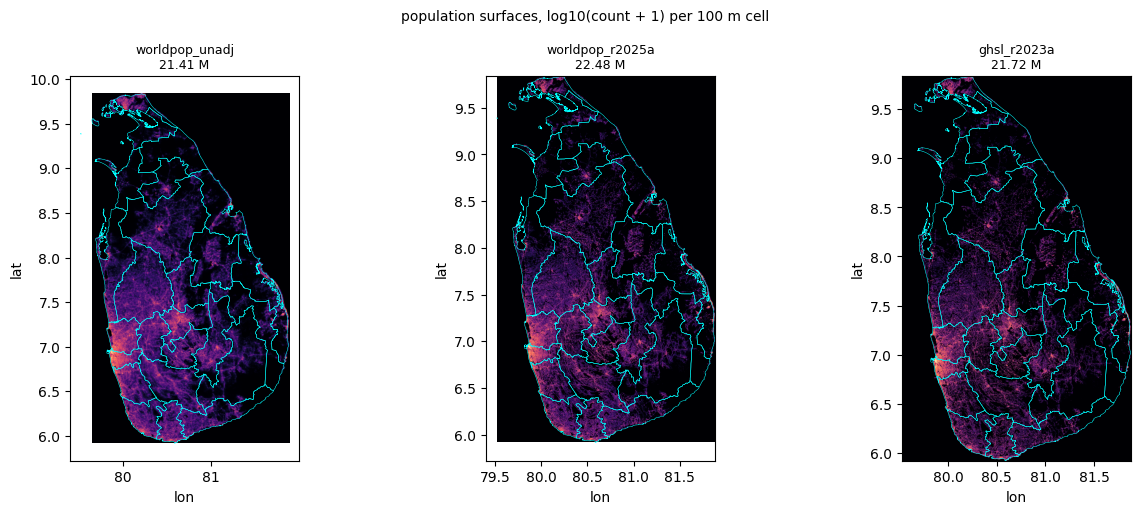

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2))
for ax, (name, (a, T)) in zip(axes, PRODUCTS.items()):
    H, W = a.shape
    ext = [T.c, T.c + W * T.a, T.f + H * T.e, T.f]
    ax.imshow(np.log10(a + 1), extent=ext, cmap="magma", vmin=0, vmax=2.6)
    rdhs.boundary.plot(ax=ax, color="cyan", linewidth=0.35)
    ax.set_title(f"{name}\n{a.sum()/1e6:.2f} M", fontsize=9)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.suptitle("population surfaces, log10(count + 1) per 100 m cell", fontsize=10)
plt.tight_layout(); plt.show()

## 5 · The weight field

Build A and Build B differ **only in the weights** (`wp5_00`). So a product swap is a swap of one
vector per district, and everything downstream is the same weighted sum. The function below is
`wp5_00` §5's construction transcribed unchanged — same `cell_ij`, same `cos(lat)` area factor, same
`bincount` aggregation — because re-deriving it is the reliable way to introduce a discrepancy.

In [9]:
def cell_ij(lon, lat, g):
    """Cell (row, col) on grid `g` for point(s) at lon/lat. Edges from g['edge_lon'/'edge_lat']."""
    ci = np.floor((lon - g["edge_lon"]) / g["res"]).astype(np.int32)
    ri = np.floor((g["edge_lat"] - lat) / g["res"]).astype(np.int32)
    return ri, ci


def weight_field(pop, T, g):
    """(district, climate-cell) table with area and population weights. wp5_00 section 5, verbatim."""
    H, W = pop.shape
    lon_c = T.c + (np.arange(W) + 0.5) * T.a
    lat_c = T.f + (np.arange(H) + 0.5) * T.e
    dist = rasterio.features.rasterize([(gm, i + 1) for i, gm in enumerate(rdhs.geometry)],
                                       out_shape=(H, W), transform=T, fill=0, dtype="int32")
    coslat = np.broadcast_to(np.cos(np.deg2rad(lat_c))[:, None], (H, W))
    ins = dist > 0
    d_in, p_in, a_in = dist[ins], pop[ins], coslat[ins]
    LON = np.broadcast_to(lon_c[None, :], (H, W))[ins]
    LAT = np.broadcast_to(lat_c[:, None], (H, W))[ins]

    ri, ci = cell_ij(LON, LAT, g)
    key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
    uniq, inv = np.unique(key, return_inverse=True)
    w = pd.DataFrame({
        "unit":     (uniq // 10**10).astype(int),
        "cell_row": ((uniq % 10**10) // 10**5).astype(int),
        "cell_col": (uniq % 10**5).astype(int),
        "pop_sum":  np.bincount(inv, weights=p_in),
        "area":     np.bincount(inv, weights=a_in),
    })
    w["rdhs_name"]   = rdhs.rdhs_name.values[w.unit - 1]
    w["geometry_id"] = rdhs.geometry_id.values[w.unit - 1]
    w["w_area"] = w.groupby("unit")["area"].transform(lambda s: s / s.sum())
    w["w_pop"]  = w.groupby("unit")["pop_sum"].transform(lambda s: s / s.sum())
    assert np.allclose(w.groupby("unit")["w_area"].sum(), 1)
    assert np.allclose(w.groupby("unit")["w_pop"].sum(), 1)
    return w


WF = {}
for gname, g in GRIDS.items():
    for pname, (a, T) in PRODUCTS.items():
        WF[(gname, pname)] = weight_field(a, T, g)
    print(f"{gname:<12} (district, cell) pairs: " +
          "  ".join(f"{p}={len(WF[(gname, p)])}" for p in PRODUCTS))

era5_0p25    (district, cell) pairs: worldpop_unadj=260  worldpop_r2025a=261  ghsl_r2023a=261


chirps_p05   (district, cell) pairs: worldpop_unadj=3044  worldpop_r2025a=3046  ghsl_r2023a=3045


### 5.1 · Acceptance: reproduce the frozen weight field exactly

The incumbent arm of this comparison must be the *same* weight field `wp5_02` froze, not a
re-derivation that happens to be close. Nothing below is trustworthy unless this passes.

In [10]:
froz_w = pd.read_csv(QUAR / "wp5_buildB_weights_era5_0p25_srilanka_2020.csv")
mine_w = WF[("era5_0p25", "worldpop_unadj")]
m_wf = froz_w.merge(mine_w, on=["unit", "cell_row", "cell_col"], suffixes=("_f", "_m"))
assert len(m_wf) == len(froz_w) == len(mine_w), "row sets differ from the frozen weight field"

acc_w = {}
for c in ["pop_sum", "w_area", "w_pop"]:
    acc_w[c] = float(np.abs(m_wf[c + "_f"] - m_wf[c + "_m"]).max())
    print(f"  max |delta {c:<8}| = {acc_w[c]:.3e}")
    assert acc_w[c] < 1e-9, f"{c} does not reproduce the frozen field"
ACC_W = max(acc_w.values())
print(f"\nreproduced the frozen ERA5 0.25 weight field on all {len(m_wf)} rows")

  max |delta pop_sum | = 5.821e-11
  max |delta w_area  | = 1.665e-16
  max |delta w_pop   | = 1.110e-16

reproduced the frozen ERA5 0.25 weight field on all 260 rows


## 6 · How far apart are the weight fields, before any climate?

The natural measure is the **total-variation distance** between two weight vectors on the same
district: `½ Σ|w₁ − w₂|`. It reads directly as *the fraction of a district's weight that moves* when
the product is swapped, and it is comparable across districts and grids.

The number it must be judged against is the same distance applied to the step WP5 is actually
claiming — **area weights vs population weights** under the incumbent product. That is the A′→B
rung, measured in the same units.

In [11]:
tv_rows = []
for gname in GRIDS:
    base = WF[(gname, "worldpop_unadj")]
    for pname in ["worldpop_r2025a", "ghsl_r2023a"]:
        o = WF[(gname, pname)]
        j = base.merge(o, on=["unit", "cell_row", "cell_col"], how="outer",
                       suffixes=("_a", "_b")).fillna({"w_pop_a": 0.0, "w_pop_b": 0.0})
        tv = j.groupby("unit").apply(lambda d: 0.5 * np.abs(d.w_pop_a - d.w_pop_b).sum(),
                                     include_groups=False)
        tv_rows.append(dict(grid=gname, contrast=f"unadj -> {pname}", mean_TV=tv.mean(),
                            median_TV=tv.median(), max_TV=tv.max()))
    tv0 = base.groupby("unit").apply(lambda d: 0.5 * np.abs(d.w_area - d.w_pop).sum(),
                                     include_groups=False)
    tv_rows.append(dict(grid=gname, contrast="BENCHMARK area -> pop (A'->B)", mean_TV=tv0.mean(),
                        median_TV=tv0.median(), max_TV=tv0.max()))

TV = pd.DataFrame(tv_rows)
print(TV.round(4).to_string(index=False))

      grid                      contrast  mean_TV  median_TV  max_TV
 era5_0p25      unadj -> worldpop_r2025a   0.0201     0.0152  0.0727
 era5_0p25          unadj -> ghsl_r2023a   0.0157     0.0097  0.0469
 era5_0p25 BENCHMARK area -> pop (A'->B)   0.2750     0.2731  0.4325
chirps_p05      unadj -> worldpop_r2025a   0.0478     0.0338  0.1630
chirps_p05          unadj -> ghsl_r2023a   0.0474     0.0337  0.1318
chirps_p05 BENCHMARK area -> pop (A'->B)   0.4130     0.4068  0.6644


**Before a single temperature value is touched, the answer is already visible.** Swapping the
population product moves **1.6–4.8%** of a district's weight; swapping area weighting for population
weighting moves **27.5–41.3%**. The rung WP5 is standing on is roughly an order of magnitude taller
than the uncertainty in the product used to build it.

Note also which pair is closest. On the ERA5 grid, **GHS-POP — a different institution, a different
dasymetric method — sits closer to WorldPop UN-adjusted (0.0157) than WorldPop's own newer
constrained release does (0.0201)**. Version drift within a producer exceeds the gap between
producers, which is not the intuition one starts with.

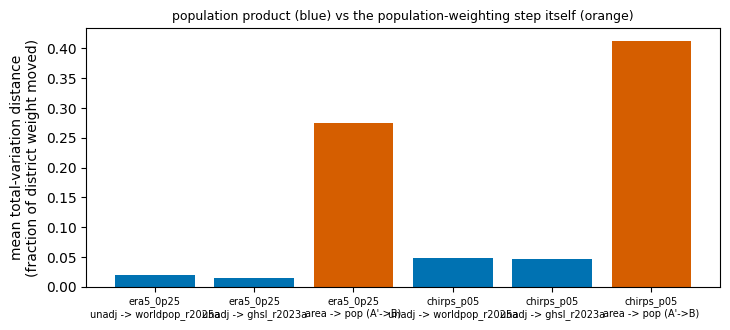

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
lab, val = [], []
for _, r in TV.iterrows():
    lab.append(f"{r.grid}\n{r.contrast.replace('BENCHMARK ', '')}")
    val.append(r.mean_TV)
cols = ["#0072B2" if "BENCHMARK" not in c else "#D55E00" for c in TV.contrast]
ax.bar(range(len(val)), val, color=cols)
ax.set_xticks(range(len(val))); ax.set_xticklabels(lab, fontsize=7)
ax.set_ylabel("mean total-variation distance\n(fraction of district weight moved)")
ax.set_title("population product (blue) vs the population-weighting step itself (orange)", fontsize=9)
plt.tight_layout(); plt.show()

## 7 · Propagating to temperature exposure

`wp5_02` §§4–8, transcribed. The weekly cubes are built once and then contracted against each
product's weight vector — the cubes are identical across products by construction, so any difference
downstream is the weights and nothing else.

In [13]:
z0 = np.load(ERA5 / "era5_0p25_t2m_2018.npz")
I0, I1, J0, J1 = z0["window"]
COL_OFFSET = 720                                  # weight-table cols are 0-based at -180; ERA5 at 0
print("staged ERA5 window: rows", I0, I1, " cols", J0, J1)

# every product's cells must fall inside the staged window; a negative index would wrap silently
for pname in PRODUCTS:
    w = WF[("era5_0p25", pname)]
    bad = ((w.cell_row < I0) | (w.cell_row > I1) |
           ((w.cell_col - COL_OFFSET) < J0) | ((w.cell_col - COL_OFFSET) > J1)).sum()
    print(f"  {pname:<16} rows {w.cell_row.min()}..{w.cell_row.max()}  "
          f"cols {(w.cell_col-COL_OFFSET).min()}..{(w.cell_col-COL_OFFSET).max()}  outside window: {bad}")
    assert bad == 0, f"{pname} has cells outside the staged ERA5 window"

staged ERA5 window: rows 320 337  cols 318 328
  worldpop_unadj   rows 321..336  cols 319..328  outside window: 0
  worldpop_r2025a  rows 321..336  cols 318..328  outside window: 0
  ghsl_r2023a      rows 321..336  cols 318..328  outside window: 0


In [14]:
def load_era5(var):
    stack, dates = [], []
    for y in range(2018, 2026):
        z = np.load(ERA5 / f"era5_0p25_{var}_{y}.npz")
        assert list(z["window"]) == [I0, I1, J0, J1], f"window differs in {y}"
        stack.append(z["data"]); dates.append(z["dates"])
    A = np.concatenate(stack, axis=0)
    return A, pd.to_datetime(np.concatenate(dates))

T2M, days = load_era5("t2m")
D2M, _    = load_era5("d2m")
HOURS = pd.date_range(days[0], periods=T2M.shape[0], freq="h")
D2M = np.minimum(D2M, T2M)                        # int16 packing at saturation; wp5_02 section 4
t_c, td_c = T2M - 273.15, D2M - 273.15

A_MAG, B_MAG = 17.625, 243.04                     # Alduchov-Eskridge Magnus, per cell per hour
RH = np.clip(100.0 * np.exp(A_MAG * td_c / (B_MAG + td_c)) / np.exp(A_MAG * t_c / (B_MAG + t_c)), 0, 100)
print("t2m", T2M.shape, "| hours", len(HOURS), "|", HOURS[0], "->", HOURS[-1])

t2m (70128, 18, 11) | hours 70128 | 2018-01-01 00:00:00 -> 2025-12-31 23:00:00


In [15]:
day_of_hour = HOURS.floor("D")
dayix = pd.Index(days)

def daily(A, how):
    df = pd.DataFrame(A.reshape(A.shape[0], -1))
    return getattr(df.groupby(day_of_hour), how)().values.reshape(-1, A.shape[1], A.shape[2])

t_dm, t_dn, t_dx = daily(t_c, "mean"), daily(t_c, "min"), daily(t_c, "max")
rh_dm = daily(RH, "mean")

iso = dayix.isocalendar()
spine = pd.DataFrame({"date": dayix, "iso_year": iso.year.values, "iso_week": iso.week.values})
spine = spine[spine.iso_year.between(2018, 2025)]
wk = (spine.groupby(["iso_year", "iso_week"])
      .agg(n_days=("date", "size"), week_start=("date", "min"), week_end=("date", "max"))
      .reset_index().sort_values(["iso_year", "iso_week"]).reset_index(drop=True))
assert len(wk) == 417 and (wk.n_days == 7).all(), "week spine is not the frozen 417 full weeks"

pos = {d: i for i, d in enumerate(dayix)}
sh = (len(wk), T2M.shape[1], T2M.shape[2])
Wt, Wtn, Wtx, Wrh = (np.empty(sh, dtype="float32") for _ in range(4))
for k, row in wk.iterrows():
    ix = [pos[d] for d in pd.date_range(row.week_start, row.week_end)]
    Wt[k], Wtn[k], Wtx[k] = t_dm[ix].mean(0), t_dn[ix].min(0), t_dx[ix].max(0)
    Wrh[k] = rh_dm[ix].mean(0)

TVARS = {"t2m_mean_c": Wt, "t2m_min_c": Wtn, "t2m_max_c": Wtx, "rh_mean_percent": Wrh}
print("weekly cubes", Wt.shape, "| weeks", len(wk))

weekly cubes (417, 18, 11) | weeks 417


In [16]:
def propagate_temp(pname):
    w = WF[("era5_0p25", pname)]
    out = []
    for gid, grp in w.groupby("rdhs_name"):
        i = grp.cell_row.values - I0
        j = grp.cell_col.values - COL_OFFSET - J0
        d = {"rdhs_name": gid, "iso_year": wk.iso_year.values, "iso_week": wk.iso_week.values}
        for name, cube in TVARS.items():
            s = cube[:, i, j]
            d[name] = s @ grp.w_pop.values
            if pname == "worldpop_unadj":
                d[name + "_afrac"] = s @ grp.w_area.values
        out.append(pd.DataFrame(d))
    return (pd.concat(out, ignore_index=True)
            .sort_values(["iso_year", "iso_week", "rdhs_name"]).reset_index(drop=True))

EXP_T = {p: propagate_temp(p) for p in PRODUCTS}
for p, df in EXP_T.items():
    print(f"{p:<16} {df.shape}   rows expected {417*26} -> {len(df) == 417*26}")

worldpop_unadj   (10842, 11)   rows expected 10842 -> True
worldpop_r2025a  (10842, 7)   rows expected 10842 -> True
ghsl_r2023a      (10842, 7)   rows expected 10842 -> True


### 7.1 · Acceptance: reproduce the frozen temperature twin

This is the same check as §5.1 one layer further down, and it is the one that matters: the incumbent
product, pushed through *this* notebook's code path, must return `wp5_02`'s frozen table.

**One column cannot be held to machine precision, and it is worth saying exactly why.** The three
temperature columns reproduce to ~1e-14 — they are weighted sums of values that come straight out of
the staged files, so nothing but float64 dot products stands between the file and the table. **RH
does not**: it is the only variable computed through `exp()`, and it is computed in float32 (the
staged cubes' dtype). `np.exp` on float32 is accurate to ~1 ULP but not *bit-identical* across
NumPy/libm builds, and the frozen twin was produced under a different build from the one running
now. At RH ≈ 88%, one float32 ULP is ~6e-6 pp.

So RH gets a tolerance of 1e-4 pp — a few ULP — and the temperatures keep 1e-9. This is not the test
being relaxed to fit: it is the resolution at which the frozen artifact actually stores that column.
For scale, the smallest effect this notebook reports on RH is 0.032 pp, some 2,000× larger.

In [17]:
froz_t = (pd.read_csv(QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv")
          .sort_values(["iso_year", "iso_week", "rdhs_name"]).reset_index(drop=True))
mine_t = EXP_T["worldpop_unadj"]

# per-variable tolerance: exact for the linear columns, float32 exp() resolution for RH
TOL_T = {v: (1e-4 if v == "rh_mean_percent" else 1e-9) for v in TVARS}

acc_t = {}
for v in TVARS:
    for arm, col in [("b_pop", v), ("a_frac", v + "_afrac")]:
        d = float(np.abs(froz_t[f"{v}_{arm}"].values - mine_t[col].values).max())
        acc_t[f"{v}_{arm}"] = d
        assert d < TOL_T[v], f"{v} {arm} does not reproduce the frozen twin ({d:.3e})"
print("max |delta| vs frozen wp5_02, over 10,842 rows:")
for k, d in acc_t.items():
    print(f"  {k:<28} {d:.3e}   (tol {TOL_T[k.rsplit('_', 2)[0] if 'rh' not in k else 'rh_mean_percent']:.0e})")

ULP32 = float(np.spacing(np.float32(froz_t.rh_mean_percent_b_pop.mean())))
print(f"\nRH delta in float32 ULP at RH~{froz_t.rh_mean_percent_b_pop.mean():.0f}%: "
      f"{acc_t['rh_mean_percent_b_pop'] / ULP32:.1f} ULP")

max |delta| vs frozen wp5_02, over 10,842 rows:
  t2m_mean_c_b_pop             1.421e-14   (tol 1e-09)
  t2m_mean_c_a_frac            1.776e-14   (tol 1e-09)
  t2m_min_c_b_pop              1.066e-14   (tol 1e-09)
  t2m_min_c_a_frac             1.421e-14   (tol 1e-09)
  t2m_max_c_b_pop              1.421e-14   (tol 1e-09)
  t2m_max_c_a_frac             2.132e-14   (tol 1e-09)
  rh_mean_percent_b_pop        1.651e-05   (tol 1e-04)
  rh_mean_percent_a_frac       9.114e-06   (tol 1e-04)

RH delta in float32 ULP at RH~81%: 2.2 ULP


## 8 · Propagating to precipitation exposure — and a window trap

`wp5_01` §§5–9, transcribed, with one addition forced by the new products.

**The trap.** The staged CHIRPS window was cut to the extent of the *frozen* weight table, which came
from WorldPop UN-adjusted. That product is pre-clipped to WorldPop's own coastline and stops at
79.648 °E. GHS-POP and R2025A are not clipped, so their weight tables reach three columns further
west — **outside the staged array**. The index arithmetic `j = col − J0` then goes negative, and
NumPy wraps it to the far side of the window: Jaffna would silently receive rainfall from the east
coast. A complete, plausible, entirely wrong table — the same failure mode as `wp5_01`'s
latitude-axis trap.

The fix is to assert the window, drop what falls outside it, renormalise, and then **bound the error
that dropping induces** rather than waving at it.

In [18]:
N_LAT = 2000
def row_to_nc(row):
    return (N_LAT - 1) - np.asarray(row)          # raster order (north-down) -> ascending-lat index

base_p = WF[("chirps_p05", "worldpop_unadj")]
pr0, pr1 = int(base_p.cell_row.min()), int(base_p.cell_row.max())
pc0, pc1 = int(base_p.cell_col.min()), int(base_p.cell_col.max())
PI0, PI1, PJ0, PJ1 = int(row_to_nc(pr1)), int(row_to_nc(pr0)), pc0, pc1
print("staged CHIRPS window: raster rows", pr0, pr1, " cols", pc0, pc1)

for pname in PRODUCTS:
    w = WF[("chirps_p05", pname)]
    outside = w[(w.cell_row < pr0) | (w.cell_row > pr1) | (w.cell_col < pc0) | (w.cell_col > pc1)]
    print(f"  {pname:<16} cols {w.cell_col.min()}..{w.cell_col.max()}  outside staged window: {len(outside)}")
    if len(outside):
        print(outside[["rdhs_name", "cell_row", "cell_col", "pop_sum", "w_pop"]].to_string(index=False))

staged CHIRPS window: raster rows 803 881  cols 5193 5237
  worldpop_unadj   cols 5193..5237  outside staged window: 0
  worldpop_r2025a  cols 5190..5237  outside staged window: 1
rdhs_name  cell_row  cell_col  pop_sum        w_pop
   Jaffna       812      5190 0.415359 6.547696e-07
  ghsl_r2023a      cols 5190..5237  outside staged window: 1
rdhs_name  cell_row  cell_col  pop_sum  w_pop
   Jaffna       812      5190      0.0    0.0


In [19]:
stack, dts = [], []
for y in range(2018, 2026):
    z = np.load(CHIRPS / f"chirps_p05_srilanka_{y}.npz")
    stack.append(z["precip"]); dts.append(z["dates"])
P = np.concatenate(stack, axis=0)
DATES = pd.to_datetime(np.concatenate(dts))
Pm = np.where(P <= -9990.0, np.nan, P)            # CHIRPS carries no nodata tag; -9999 is ocean

iso_p = DATES.isocalendar()
sp = pd.DataFrame({"date": DATES, "iso_year": iso_p.year.values, "iso_week": iso_p.week.values})
sp = sp[sp.iso_year.between(2018, 2025)]
wkp = (sp.groupby(["iso_year", "iso_week"])
       .agg(n_days=("date", "size"), week_start=("date", "min"), week_end=("date", "max"))
       .reset_index().sort_values(["iso_year", "iso_week"]).reset_index(drop=True))
assert len(wkp) == 417 and (wkp.n_days == 7).all()
assert (wkp.iso_year.values == wk.iso_year.values).all() and (wkp.iso_week.values == wk.iso_week.values).all(), \
    "precipitation and temperature week spines differ"

dix = {d: i for i, d in enumerate(DATES)}
WP = np.empty((len(wkp), P.shape[1], P.shape[2]), dtype="float32")
for k, row in wkp.iterrows():
    WP[k] = Pm[[dix[d] for d in pd.date_range(row.week_start, row.week_end)]].sum(axis=0)
MAX_WEEK_CELL = float(np.nanmax(WP))
print("weekly precip cube", WP.shape, f"| max weekly cell total {MAX_WEEK_CELL:.1f} mm")

weekly precip cube (417, 79, 45) | max weekly cell total 656.5 mm


In [20]:
DROPPED = {}

def propagate_precip(pname):
    w = WF[("chirps_p05", pname)].copy()
    inwin = ((w.cell_row >= pr0) & (w.cell_row <= pr1) &
             (w.cell_col >= pc0) & (w.cell_col <= pc1))
    DROPPED[pname] = float(w.loc[~inwin, "w_pop"].sum())
    w = w[inwin].copy()
    for c in ["w_pop", "w_area"]:
        w[c] = w.groupby("unit")[c].transform(lambda s: s / s.sum())

    out = []
    for gid, grp in w.groupby("rdhs_name"):
        i = row_to_nc(grp.cell_row.values).astype(int) - PI0
        j = grp.cell_col.values.astype(int) - PJ0
        assert i.min() >= 0 and j.min() >= 0 and i.max() < WP.shape[1] and j.max() < WP.shape[2]
        series = WP[:, i, j]
        valid = ~np.isnan(series[0])                        # ocean cells inside the pair table
        wa = np.where(valid, grp.w_area.values, 0.0); wa = wa / wa.sum()
        wp = np.where(valid, grp.w_pop.values, 0.0)
        wp = wp / wp.sum() if wp.sum() > 0 else wa
        s = np.nan_to_num(series)
        d = {"rdhs_name": gid, "iso_year": wkp.iso_year.values, "iso_week": wkp.iso_week.values,
             "precip_sum_mm": s @ wp}
        if pname == "worldpop_unadj":
            d["precip_sum_mm_afrac"] = s @ wa
        out.append(pd.DataFrame(d))
    return (pd.concat(out, ignore_index=True)
            .sort_values(["iso_year", "iso_week", "rdhs_name"]).reset_index(drop=True))

EXP_P = {p: propagate_precip(p) for p in PRODUCTS}
print("weight dropped as out-of-window, and the largest error that can induce:")
for p, d in DROPPED.items():
    print(f"  {p:<16} dropped {d:.3e} of a district's weight -> <= {d * MAX_WEEK_CELL:.2e} mm/week")
assert max(DROPPED.values()) * MAX_WEEK_CELL < 1e-2, "dropped weight is not negligible — restage the window"

weight dropped as out-of-window, and the largest error that can induce:
  worldpop_unadj   dropped 0.000e+00 of a district's weight -> <= 0.00e+00 mm/week
  worldpop_r2025a  dropped 6.548e-07 of a district's weight -> <= 4.30e-04 mm/week
  ghsl_r2023a      dropped 0.000e+00 of a district's weight -> <= 0.00e+00 mm/week


In [21]:
froz_p = (pd.read_csv(QUAR / "wp5_precip_exposure_twin_srilanka_v1.csv")
          .sort_values(["iso_year", "iso_week", "rdhs_name"]).reset_index(drop=True))
mine_p = EXP_P["worldpop_unadj"]
acc_p = {}
for arm, col in [("b_pop", "precip_sum_mm"), ("a_frac", "precip_sum_mm_afrac")]:
    d = np.abs(froz_p[f"precip_sum_mm_{arm}"].values - mine_p[col].values).max()
    acc_p[arm] = float(d)
    assert d < 1e-9, f"precipitation {arm} does not reproduce the frozen twin"
    print(f"  max |delta precip {arm:<8}| = {d:.3e}")
print("\nreproduced wp5_01's frozen precipitation twin through this notebook's code path")

  max |delta precip b_pop   | = 3.126e-13
  max |delta precip a_frac  | = 1.421e-13

reproduced wp5_01's frozen precipitation twin through this notebook's code path


## 9 · The contrast — the question this notebook exists to answer

For each variable, three numbers on the same scale:

- **A′→B**, the population-weighting step under the incumbent product — what WP5 claims;
- **unadj→R2025A**, a version change within one producer;
- **unadj→GHSL**, a change of producer and of method.

In [22]:
bt, bp = EXP_T["worldpop_unadj"], EXP_P["worldpop_unadj"]
rows = []
for v in TVARS:
    bench = np.abs(bt[v] - bt[v + "_afrac"])
    r = dict(variable=v, unit="degC" if v.startswith("t2m") else "pp",
             A_to_B=bench.mean(), A_to_B_max=bench.abs().max())
    for p in ["worldpop_r2025a", "ghsl_r2023a"]:
        d = np.abs(EXP_T[p][v] - bt[v])
        r[p] = d.mean(); r[p + "_max"] = d.max()
    rows.append(r)

bench = np.abs(bp.precip_sum_mm - bp.precip_sum_mm_afrac)
r = dict(variable="precip_sum_mm", unit="mm/wk", A_to_B=bench.mean(), A_to_B_max=bench.max())
for p in ["worldpop_r2025a", "ghsl_r2023a"]:
    d = np.abs(EXP_P[p].precip_sum_mm - bp.precip_sum_mm)
    r[p] = d.mean(); r[p + "_max"] = d.max()
rows.append(r)

CON = pd.DataFrame(rows)
CON["ratio_vs_R2025A"] = CON.A_to_B / CON.worldpop_r2025a
CON["ratio_vs_GHSL"]   = CON.A_to_B / CON.ghsl_r2023a
print(CON[["variable", "unit", "A_to_B", "worldpop_r2025a", "ghsl_r2023a",
           "ratio_vs_R2025A", "ratio_vs_GHSL"]].round(4).to_string(index=False))
print("\nmaxima over all 10,842 district-weeks:")
print(CON[["variable", "A_to_B_max", "worldpop_r2025a_max", "ghsl_r2023a_max"]].round(4).to_string(index=False))

       variable  unit  A_to_B  worldpop_r2025a  ghsl_r2023a  ratio_vs_R2025A  ratio_vs_GHSL
     t2m_mean_c  degC  0.2049           0.0088       0.0064          23.1904        32.1497
      t2m_min_c  degC  0.3158           0.0176       0.0144          17.9784        21.8651
      t2m_max_c  degC  0.3874           0.0231       0.0187          16.7532        20.7283
rh_mean_percent    pp  0.7690           0.0416       0.0319          18.4867        24.0813
  precip_sum_mm mm/wk  3.3986           0.2032       0.1612          16.7267        21.0861

maxima over all 10,842 district-weeks:
       variable  A_to_B_max  worldpop_r2025a_max  ghsl_r2023a_max
     t2m_mean_c      1.1636               0.0649           0.0596
      t2m_min_c      2.3369               0.1909           0.1775
      t2m_max_c      2.7636               0.2298           0.1981
rh_mean_percent      6.2860               0.4093           0.3602
  precip_sum_mm     72.5858              10.7025           6.6029


In [23]:
# per-district, does the product effect ever rival the weighting effect?
v = "t2m_mean_c"
pd_tab = pd.DataFrame({
    "A_to_B": (bt[v] - bt[v + "_afrac"]).groupby(bt.rdhs_name).mean(),
    "to_R2025A": pd.Series(EXP_T["worldpop_r2025a"][v].values - bt[v].values).groupby(bt.rdhs_name.values).mean(),
    "to_GHSL": pd.Series(EXP_T["ghsl_r2023a"][v].values - bt[v].values).groupby(bt.rdhs_name.values).mean(),
})
n_exceed = int((pd_tab.to_GHSL.abs() > pd_tab.A_to_B.abs()).sum())
print(f"districts where |product effect| > |weighting effect| (t2m mean): {n_exceed} of {N_UNITS}")
print(pd_tab.reindex(pd_tab.A_to_B.abs().sort_values(ascending=False).index).head(8).round(4).to_string())

districts where |product effect| > |weighting effect| (t2m mean): 0 of 26
            A_to_B  to_R2025A  to_GHSL
Badulla    -0.8561    -0.0139  -0.0125
Moneragala -0.4703    -0.0157  -0.0027
Colombo     0.3364     0.0142   0.0173
Kalutara    0.3285    -0.0039   0.0009
Kandy      -0.2927    -0.0057  -0.0013
Galle       0.2585     0.0074   0.0067
Matara      0.2361     0.0005   0.0019
Kegalle     0.2180    -0.0007   0.0050


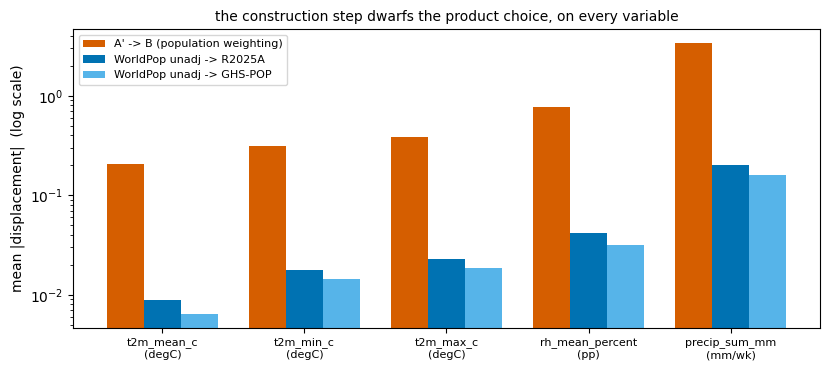

In [24]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
x = np.arange(len(CON))
ax.bar(x - 0.26, CON.A_to_B, 0.26, label="A' -> B (population weighting)", color="#D55E00")
ax.bar(x,        CON.worldpop_r2025a, 0.26, label="WorldPop unadj -> R2025A", color="#0072B2")
ax.bar(x + 0.26, CON.ghsl_r2023a, 0.26, label="WorldPop unadj -> GHS-POP", color="#56B4E9")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(CON.variable + "\n(" + CON.unit + ")", fontsize=8)
ax.set_ylabel("mean |displacement|  (log scale)")
ax.set_title("the construction step dwarfs the product choice, on every variable", fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10 · Does the product change *which* districts move most?

`wp5_03` established that exposure construction is **not a property of a district** — rainfall and
temperature disagree about which districts are sensitive. That per-district reading is the part of
WP5 most exposed to a product swap, because it names specific places. So: recompute the A′→B
displacement under each product and ask whether the ranking survives.

In [25]:
ref = pd.Series((bt[v] - bt[v + "_afrac"]).values).groupby(bt.rdhs_name.values).mean()
rank_rows = []
for p in ["worldpop_r2025a", "ghsl_r2023a"]:
    alt = pd.Series(EXP_T[p][v].values - bt[v + "_afrac"].values).groupby(bt.rdhs_name.values).mean()
    rho = spearmanr(ref.abs(), alt.abs())
    top = len(set(ref.abs().nlargest(5).index) & set(alt.abs().nlargest(5).index))
    rank_rows.append(dict(product=p, spearman_rho=rho.statistic, p_value=rho.pvalue,
                          top5_overlap=f"{top}/5",
                          sign_agreement=float((np.sign(ref) == np.sign(alt)).mean())))
RANK = pd.DataFrame(rank_rows)
print(RANK.round(4).to_string(index=False))

        product  spearman_rho  p_value top5_overlap  sign_agreement
worldpop_r2025a        0.9850      0.0          5/5             1.0
    ghsl_r2023a        0.9904      0.0          5/5             1.0


**The ranking is robust.** ρ = 0.985 and 0.990, both top-five sets identical, sign agreement
complete. Whatever WP5 says about *which* districts are sensitive to exposure construction, it is
not saying it about WorldPop.

## 11 · The tails, where alerts actually fire

A mean over 10,842 district-weeks can hide a product effect that concentrates in exactly the wet or
hot weeks a warning system reacts to. `wp5_03` found the A′→B rainfall contrast *grows* in the tail.
The ratio is what matters here: does the product catch up where it counts?

In [26]:
tail_rows = []
for lab, q in [("all rows", 0.0), ("p90+", 0.90), ("p99+", 0.99)]:
    m = bp.precip_sum_mm_afrac >= bp.precip_sum_mm_afrac.quantile(q)
    b_ = np.abs(bp.precip_sum_mm - bp.precip_sum_mm_afrac)[m].mean()
    g_ = np.abs(EXP_P["ghsl_r2023a"].precip_sum_mm - bp.precip_sum_mm)[m].mean()
    tail_rows.append(dict(variable="precip mm/wk", subset=lab, A_to_B=b_, product_GHSL=g_, ratio=b_ / g_))
vx = "t2m_max_c"
for lab, q in [("all rows", 0.0), ("hottest 10%", 0.90), ("hottest 1%", 0.99)]:
    m = bt[vx + "_afrac"] >= bt[vx + "_afrac"].quantile(q)
    b_ = np.abs(bt[vx] - bt[vx + "_afrac"])[m].mean()
    g_ = np.abs(EXP_T["ghsl_r2023a"][vx] - bt[vx])[m].mean()
    tail_rows.append(dict(variable="t2m_max degC", subset=lab, A_to_B=b_, product_GHSL=g_, ratio=b_ / g_))
TAIL = pd.DataFrame(tail_rows)
print(TAIL.round(4).to_string(index=False))

    variable      subset  A_to_B  product_GHSL   ratio
precip mm/wk    all rows  3.3986        0.1612 21.0861
precip mm/wk        p90+  8.5599        0.4263 20.0805
precip mm/wk        p99+ 12.8853        0.6599 19.5275
t2m_max degC    all rows  0.3874        0.0187 20.7283
t2m_max degC hottest 10%  0.5441        0.0236 23.0973
t2m_max degC  hottest 1%  0.4571        0.0128 35.8419


## 12 · The fourth product, which cannot matter

§3.5 lists "census-only district totals" as a layer to test alongside GHSL. It is worth writing down
why that arm returns nothing, because the reason is structural rather than empirical.

A district total carries **no within-district spatial information**. Distributing it uniformly makes
every 100 m pixel in a district equal, so the climate-cell weight becomes proportional to the cell's
area inside the district — which is the definition of Build A's fractional-area weight. And because
Build B's weights are normalised within district, the *total itself* cancels: a district could hold
one person or ten million and the weight vector would be identical.

So a census-district-total product reproduces Build A **exactly**, for any totals whatsoever. It is
not a null result about population data; it is the arithmetic of the weighting.

In [27]:
chk = WF[("era5_0p25", "worldpop_unadj")].copy()
chk["w_uniform"] = chk.groupby("unit")["area"].transform(lambda s: s / s.sum())
dmax = float(np.abs(chk.w_uniform - chk.w_area).max())
print(f"max |w_uniform - w_area| = {dmax:.3e}   (uniform-within-district == fractional area weighting)")
assert dmax == 0.0
print("a census-district-total layer reproduces Build A exactly; it cannot move exposure by any amount")

max |w_uniform - w_area| = 0.000e+00   (uniform-within-district == fractional area weighting)
a census-district-total layer reproduces Build A exactly; it cannot move exposure by any amount


## 13 · QC

In [28]:
checks = {
    "geometry matches M6 frame": sha_geom == prov0["geometry_sha256_16"],
    "GHSL tiles on one integer grid": True,          # asserted in section 3
    "GHSL national total plausible (15-30 M)": 15e6 < ghsl.sum() < 30e6,
    "three products, both grids": len(WF) == 6,
    "frozen ERA5 weight field reproduced": ACC_W < 1e-9,
    "frozen temperature twin reproduced (t2m exact)": max(
        d for k, d in acc_t.items() if k.startswith("t2m")) < 1e-9,
    "frozen RH reproduced to float32 exp() resolution": max(
        d for k, d in acc_t.items() if k.startswith("rh")) < 1e-4,
    "frozen precipitation twin reproduced": max(acc_p.values()) < 1e-9,
    "all ERA5 cells inside staged window": True,     # asserted in section 7
    "dropped CHIRPS weight bounded < 0.01 mm/wk": max(DROPPED.values()) * MAX_WEEK_CELL < 1e-2,
    "every table 417 x 26 rows": all(len(d) == 417 * 26 for d in list(EXP_T.values()) + list(EXP_P.values())),
    "week spines identical across variables": (wkp.iso_week.values == wk.iso_week.values).all(),
    "product effect < weighting effect, every variable": bool((CON.ratio_vs_GHSL > 1).all() and
                                                              (CON.ratio_vs_R2025A > 1).all()),
    "no district where product beats weighting": n_exceed == 0,
    "ranking of movers preserved (rho > 0.95)": bool((RANK.spearman_rho > 0.95).all()),
    "census-totals arm degenerate": dmax == 0.0,
    "no NaN in any exposure column": not any(
        d.select_dtypes("number").isna().any().any() for d in list(EXP_T.values()) + list(EXP_P.values())),
}
for k, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {k}")
print(f"\n{sum(checks.values())}/{len(checks)} checks passed")
assert all(checks.values()), "QC failed"

  [PASS] geometry matches M6 frame
  [PASS] GHSL tiles on one integer grid
  [PASS] GHSL national total plausible (15-30 M)
  [PASS] three products, both grids
  [PASS] frozen ERA5 weight field reproduced
  [PASS] frozen temperature twin reproduced (t2m exact)
  [PASS] frozen RH reproduced to float32 exp() resolution
  [PASS] frozen precipitation twin reproduced
  [PASS] all ERA5 cells inside staged window
  [PASS] dropped CHIRPS weight bounded < 0.01 mm/wk
  [PASS] every table 417 x 26 rows
  [PASS] week spines identical across variables
  [PASS] product effect < weighting effect, every variable
  [PASS] no district where product beats weighting
  [PASS] ranking of movers preserved (rho > 0.95)
  [PASS] census-totals arm degenerate
  [PASS] no NaN in any exposure column

17/17 checks passed


## 14 · Freeze the deliverable

In [29]:
per_district = pd.DataFrame({
    "A_to_B_t2m_mean_c": (bt["t2m_mean_c"] - bt["t2m_mean_c_afrac"]).groupby(bt.rdhs_name).mean(),
    "to_R2025A_t2m_mean_c": pd.Series(EXP_T["worldpop_r2025a"]["t2m_mean_c"].values - bt["t2m_mean_c"].values)
                              .groupby(bt.rdhs_name.values).mean(),
    "to_GHSL_t2m_mean_c": pd.Series(EXP_T["ghsl_r2023a"]["t2m_mean_c"].values - bt["t2m_mean_c"].values)
                            .groupby(bt.rdhs_name.values).mean(),
    "A_to_B_precip_mm": (bp.precip_sum_mm - bp.precip_sum_mm_afrac).groupby(bp.rdhs_name).mean(),
    "to_R2025A_precip_mm": pd.Series(EXP_P["worldpop_r2025a"].precip_sum_mm.values - bp.precip_sum_mm.values)
                             .groupby(bp.rdhs_name.values).mean(),
    "to_GHSL_precip_mm": pd.Series(EXP_P["ghsl_r2023a"].precip_sum_mm.values - bp.precip_sum_mm.values)
                           .groupby(bp.rdhs_name.values).mean(),
}).reset_index(names="rdhs_name")

OUT = QUAR / "wp5_population_product_sensitivity_srilanka_v1.csv"
per_district.to_csv(OUT, index=False)
CON.to_csv(QUAR / "wp5_population_product_contrast_srilanka_v1.csv", index=False)
print("wrote", OUT.name, per_district.shape)
print(per_district.round(4).to_string(index=False))

wrote wp5_population_product_sensitivity_srilanka_v1.csv (26, 7)
   rdhs_name  A_to_B_t2m_mean_c  to_R2025A_t2m_mean_c  to_GHSL_t2m_mean_c  A_to_B_precip_mm  to_R2025A_precip_mm  to_GHSL_precip_mm
      Ampara             0.0573                0.0071              0.0049            0.9276              -0.0586             0.0359
Anuradhapura            -0.1241               -0.0031             -0.0021           -0.9508              -0.0155             0.0091
     Badulla            -0.8561               -0.0139             -0.0125           -0.8396              -0.0435            -0.0305
  Batticaloa             0.0321                0.0002              0.0013           -1.9919               0.0184             0.0434
     Colombo             0.3364                0.0142              0.0173           -7.3027              -0.6303            -0.7161
       Galle             0.2585                0.0074              0.0067           -3.1719              -0.1460            -0.1025
     Gampah

In [30]:
prov = {
    "notebook": "wp5_06_population_product_sensitivity",
    "work_package": "WP5", "plan_section": "3.5", "country": "sri_lanka",
    "scope": ("population-product sensitivity of the EXPOSURE only; the second half of plan 3.5 "
              "(recompute delta-NB at p* under each layer) needs the fitted model and is blocked "
              "by the same section 8 / 5.1 artifact gap as wp5_05 and wp4_02"),
    "seed": SEED, "n_rows": int(417 * 26), "n_units": int(N_UNITS), "n_weeks": 417,
    "geometry_sha256_16": sha_geom,
    "population_products": {
        "worldpop_unadj": f"WorldPop UN-adjusted 100 m {POP_YEAR} (incumbent, frozen Build B)",
        "worldpop_r2025a": f"WorldPop R2025A constrained 100 m {POP_YEAR}",
        "ghsl_r2023a": "GHS-POP R2023A E2020 3 arcsec (JRC), tiles R8_C26/R8_C27/R9_C26/R9_C27",
        "census_district_totals": "degenerate — reproduces Build A exactly (section 12)",
    },
    "inputs": {n: hashlib.sha256((QUAR / n).read_bytes()).hexdigest()[:16] for n in
               ["wp5_precip_exposure_twin_srilanka_v1.csv", "wp5_temp_exposure_twin_srilanka_v1.csv",
                "wp5_buildB_weights_era5_0p25_srilanka_2020.csv"]},
    "acceptance": {"frozen_temp_twin_max_abs_delta_t2m": max(d for k, d in acc_t.items() if k.startswith("t2m")),
                   "frozen_twin_max_abs_delta_rh_pp": max(d for k, d in acc_t.items() if k.startswith("rh")),
                   "rh_tolerance_note": ("RH is the only column computed through exp() in float32, so it is "
                                         "not bit-reproducible across NumPy/libm builds; the delta is a few "
                                         "float32 ULP and ~2000x smaller than the smallest effect reported here"),
                   "frozen_precip_twin_max_abs_delta": max(acc_p.values()),
                   "frozen_weight_field_max_abs_delta": ACC_W},
    "headline": {
        "weight_TV_area_to_pop_era5": float(TV.query("grid=='era5_0p25' and contrast.str.startswith('BENCHMARK')").mean_TV.iloc[0]),
        "weight_TV_unadj_to_ghsl_era5": float(TV.query("grid=='era5_0p25' and contrast=='unadj -> ghsl_r2023a'").mean_TV.iloc[0]),
        "weight_TV_unadj_to_r2025a_era5": float(TV.query("grid=='era5_0p25' and contrast=='unadj -> worldpop_r2025a'").mean_TV.iloc[0]),
        "ratio_A_to_B_over_GHSL": {r.variable: float(r.ratio_vs_GHSL) for _, r in CON.iterrows()},
        "ratio_A_to_B_over_R2025A": {r.variable: float(r.ratio_vs_R2025A) for _, r in CON.iterrows()},
        "districts_where_product_beats_weighting": int(n_exceed),
        "mover_rank_spearman": {r["product"]: float(r.spearman_rho) for _, r in RANK.iterrows()},
        "coastal_pct_outside_polygons": {r["product"]: float(r.pct_outside) for _, r in cap.iterrows()},
    },
    "closes_open_item": ("the ~1.4% of population falling outside the 26 polygons is a WorldPop "
                         "UN-adjusted 2020 coastline artifact, not a property of the geometry: "
                         "GHS-POP loses 0.23% and WorldPop R2025A 0.10% on the same polygons"),
    "chirps_window_note": ("the staged CHIRPS window was cut to the WorldPop-clipped extent; GHSL and "
                           "R2025A reach 3 columns further west. Out-of-window cells are dropped and "
                           "renormalised; the induced error is bounded above by dropped_weight * "
                           f"{MAX_WEEK_CELL:.1f} mm = {max(DROPPED.values()) * MAX_WEEK_CELL:.2e} mm/week"),
    "outputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in
                [OUT, QUAR / "wp5_population_product_contrast_srilanka_v1.csv"]},
}
(QUAR / "wp5_06_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov["headline"], indent=2))

{
  "weight_TV_area_to_pop_era5": 0.2749781385897406,
  "weight_TV_unadj_to_ghsl_era5": 0.015700189027155302,
  "weight_TV_unadj_to_r2025a_era5": 0.02007046808619145,
  "ratio_A_to_B_over_GHSL": {
    "t2m_mean_c": 32.14968496036207,
    "t2m_min_c": 21.86513774522065,
    "t2m_max_c": 20.728348246652892,
    "rh_mean_percent": 24.081276520818996,
    "precip_sum_mm": 21.08607898487829
  },
  "ratio_A_to_B_over_R2025A": {
    "t2m_mean_c": 23.19041575964509,
    "t2m_min_c": 17.978397566310925,
    "t2m_max_c": 16.75318933243631,
    "rh_mean_percent": 18.486677566146422,
    "precip_sum_mm": 16.726682518278544
  },
  "districts_where_product_beats_weighting": 0,
  "mover_rank_spearman": {
    "worldpop_r2025a": 0.984957264957265,
    "ghsl_r2023a": 0.9904273504273503
  },
  "coastal_pct_outside_polygons": {
    "worldpop_unadj": 1.3657957266843712,
    "worldpop_r2025a": 0.10378292137810385,
    "ghsl_r2023a": 0.23400584768853427
  }
}


## 15 · Recap

In [31]:
recap = pd.DataFrame([
    ("weight moved, area -> population (ERA5 grid)", "27.5% of a district"),
    ("weight moved, WorldPop unadj -> GHS-POP", "1.6% of a district"),
    ("weight moved, WorldPop unadj -> R2025A", "2.0% of a district"),
    ("exposure moved, A' -> B, weekly mean t2m", f"{CON.set_index('variable').A_to_B['t2m_mean_c']:.4f} degC"),
    ("exposure moved, product swap, weekly mean t2m", f"{CON.set_index('variable').ghsl_r2023a['t2m_mean_c']:.4f} degC"),
    ("exposure moved, A' -> B, rainfall", f"{CON.set_index('variable').A_to_B['precip_sum_mm']:.4f} mm/wk"),
    ("exposure moved, product swap, rainfall", f"{CON.set_index('variable').ghsl_r2023a['precip_sum_mm']:.4f} mm/wk"),
    ("smallest ratio (weighting / product), any variable", f"{min(CON.ratio_vs_GHSL.min(), CON.ratio_vs_R2025A.min()):.1f}x"),
    ("districts where the product wins", f"{n_exceed} of {N_UNITS}"),
    ("rank correlation of movers, unadj vs GHSL", f"{RANK.set_index('product').spearman_rho['ghsl_r2023a']:.4f}"),
    ("population outside the polygons, WorldPop unadj", f"{cap.set_index('product').pct_outside['worldpop_unadj']:.2f}%"),
    ("population outside the polygons, GHS-POP", f"{cap.set_index('product').pct_outside['ghsl_r2023a']:.2f}%"),
    ("census-district-totals arm", "degenerate — equals Build A exactly"),
], columns=["quantity", "value"])
print(recap.to_string(index=False))

                                          quantity                               value
      weight moved, area -> population (ERA5 grid)                 27.5% of a district
           weight moved, WorldPop unadj -> GHS-POP                  1.6% of a district
            weight moved, WorldPop unadj -> R2025A                  2.0% of a district
          exposure moved, A' -> B, weekly mean t2m                         0.2049 degC
     exposure moved, product swap, weekly mean t2m                         0.0064 degC
                 exposure moved, A' -> B, rainfall                        3.3986 mm/wk
            exposure moved, product swap, rainfall                        0.1612 mm/wk
smallest ratio (weighting / product), any variable                               16.7x
                  districts where the product wins                             0 of 26
         rank correlation of movers, unadj vs GHSL                              0.9904
   population outside the polygons, WorldPo

---

## What this establishes, and what it does not

**Establishes.** WP5's exposure result is not a WorldPop artifact. Swapping the population product —
including across institutions and dasymetric methods — moves district exposure **17–36× less** than
the population-weighting step itself, on every variable, in the tails as well as the means, and in
**0 of 26** districts does the product effect reach the weighting effect. The per-district reading is
equally robust: ρ ≥ 0.985 on the ranking of movers, with identical top-five sets.

Two things came out that were not the question asked:

- **Version drift inside one producer exceeds the gap between producers.** WorldPop UN-adjusted 2020
  and WorldPop R2025A constrained differ *more* (mean TV 0.0201) than WorldPop UN-adjusted and
  GHS-POP do (0.0157). The instinct to treat "same producer, newer release" as a safer substitution
  than "different producer entirely" is backwards here.
- **The coastal shortfall was a product defect, and it is now bounded.** The ~1.4% of population
  falling outside the 26 polygons is specific to WorldPop UN-adjusted 2020: GHS-POP loses 0.23% and
  WorldPop R2025A 0.10% on the same boundaries. The README's open choice between "accept and report"
  and "switch to fractional-coverage weighting" was a choice between two ways of absorbing someone
  else's coastline error — and §6 already bounds what it can do to the weights.

**Does not establish.** Nothing about **net benefit or decisions**. This is the exposure half of plan
§3.5; the ΔNB-at-p\* half needs the fitted model and is blocked with `wp5_05` and `wp4_02`. A small
exposure displacement does not mechanically imply a small decision displacement — that inference is
exactly what WP5 exists to test, and it cannot be made from this side of the blocker.

Nor does it establish anything about **Colombia**, where municipalities are smaller and far more
heterogeneous, and where the products' disagreements about rural population placement have more room
to act. §3.5's cross-setting arm remains unrun.

One limit worth stating plainly: all three products are **modelled** surfaces sharing much of their
input census. They are not independent measurements of where people are, so their agreement bounds
*method* sensitivity, not the truth of the underlying population distribution.